In [25]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import time

# Check which device is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using {}'.format(device))

# 1) Read CSV (adjust path to where your file actually is)
df = pd.read_csv("spiralsdataset.csv", header=None, names=["x1", "x2", "y"])

# 2) Features (N, 2) as float32
X = torch.tensor(df[["x1", "x2"]].values, dtype=torch.float32)

# 3) Labels (N, 1) as float32 for BCEWithLogitsLoss
y = torch.tensor(df[["y"]].values, dtype=torch.float32)

X = X.to(device)
y = y.to(device)

print(X.shape, y.shape)   # should be (N, 2) and (N, 1)
print(X[:5], y[:5])


Using cuda
torch.Size([194, 2]) torch.Size([194, 1])
tensor([[ 6.5000,  0.0000],
        [-6.5000, -0.0000],
        [ 6.3138,  1.2559],
        [-6.3138, -1.2559],
        [ 5.8897,  2.4396]], device='cuda:0') tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]], device='cuda:0')


In [26]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2,512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 1)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [27]:
MAX_EPOCHS = 10000
LOSS_GOAL = 0.1
epoch = 0
losses = []
best_loss = float("inf")
start_time = time.perf_counter()

while best_loss > LOSS_GOAL and epoch < MAX_EPOCHS:
    optimizer.zero_grad()

    logits = model(X)                 # X should be shape (N, 2)
    loss = criterion(logits, y)       # y should be shape (N, 1) float

    loss.backward()
    optimizer.step()

    loss_value = loss.item()
    losses.append(loss_value)

    if loss_value < best_loss:
        best_loss = loss_value

    if epoch % 100 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            acc = (preds == y).float().mean().item()
        print(f"Epoch {epoch} | loss {loss_value:.4f} | acc {acc:.4f} | best {best_loss:.4f}")

    epoch += 1
if device == "cuda":
    torch.cuda.synchronize()

end_time = time.perf_counter()
print(f"Training took {end_time - start_time:.4f} seconds")

Epoch 0 | loss 0.6920 | acc 0.5103 | best 0.6920
Epoch 100 | loss 0.5895 | acc 0.6186 | best 0.5895
Epoch 200 | loss 0.4443 | acc 0.7113 | best 0.4443
Epoch 300 | loss 0.3691 | acc 0.7216 | best 0.3691
Epoch 400 | loss 0.3100 | acc 0.7990 | best 0.3100
Epoch 500 | loss 0.2413 | acc 0.9175 | best 0.2413
Epoch 600 | loss 0.1706 | acc 0.9536 | best 0.1674
Epoch 700 | loss 0.1018 | acc 1.0000 | best 0.1018
Training took 1.6669 seconds


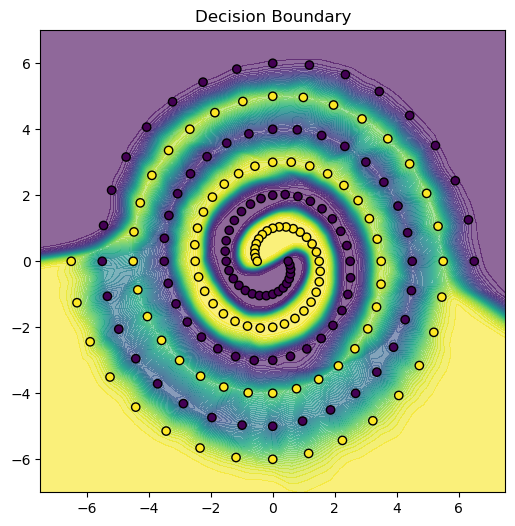

In [28]:
import numpy as np

# Create grid of points
x_min, x_max = X[:,0].min().item() - 1, X[:,0].max().item() + 1
y_min, y_max = X[:,1].min().item() - 1, X[:,1].max().item() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = torch.tensor(
    np.c_[xx.ravel(), yy.ravel()],
    dtype=torch.float32
).to(device)

# Get model predictions
with torch.no_grad():
    logits = model(grid)
    probs = torch.sigmoid(logits)
    Z = probs.reshape(xx.shape).cpu().numpy()

# Plot
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=50, alpha=0.6)
plt.scatter(X[:,0].cpu(), X[:,1].cpu(), c=y.cpu(), edgecolors='k')
plt.title("Decision Boundary")
plt.show()


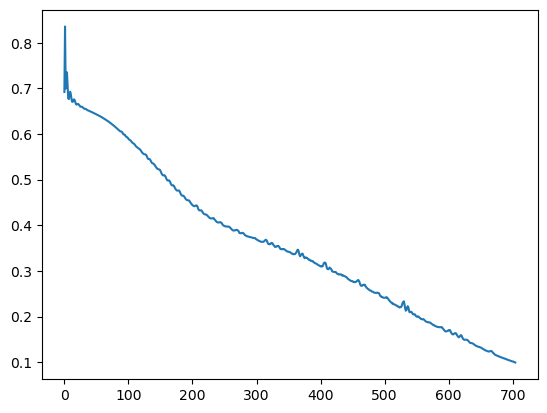

In [29]:
plt.plot(losses)
plt.show()

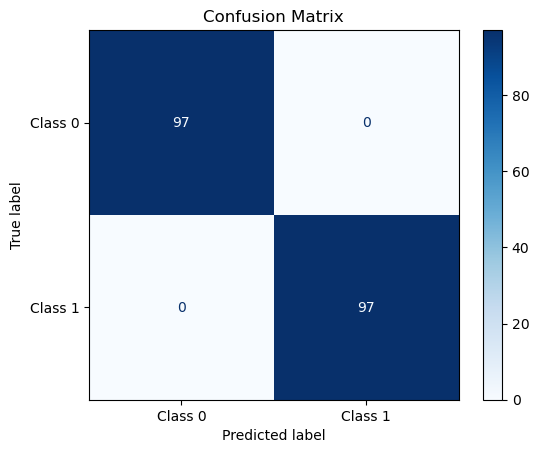

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix

with torch.no_grad():
    logits = model(X)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

# Move tensors to CPU for sklearn
y_true = y.cpu().numpy()
y_pred = preds.cpu().numpy()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Class 0","Class 1"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()